   LINEAR ALGEBRA - NUMPY

--- PART A: Matrix & Determinant ---
Matrix A:
[[2 3 1]
 [4 1 2]
 [1 5 3]]

Determinant of A: -25.0000

--- PART B: Inverse of Matrix ---
Inverse of A:
[[ 0.28  0.16 -0.2 ]
 [ 0.4  -0.2   0.  ]
 [-0.76  0.28  0.4 ]]

Verification (A × A_inv) = Identity:
[[ 1.  0.  0.]
 [ 0.  1.  0.]
 [-0.  0.  1.]]

--- PART C: Solve Linear Equations ---
Equations:
  2x + 3y = 10
  4x + 5y = 20

Solution:
  x = 5.0000
  y = 0.0000

Verification:
  2(5.00) + 3(0.00) = 10.00  (expected 10)
  4(5.00) + 5(0.00) = 20.00  (expected 20)

--- PART D: Eigenvalues & Eigenvectors ---
Eigenvalues:
[ 7.1858  1.3643 -2.5501]

Eigenvectors:
[[-0.4426 -0.4528  0.349 ]
 [-0.5219 -0.1941 -0.7266]
 [-0.7292  0.8702  0.5917]]

--- PART E: Matrix Operations ---
Matrix B:
[[1 0 2]
 [3 1 0]
 [0 2 1]]

A + B:
[[3 3 3]
 [7 2 2]
 [1 7 4]]

A × B (Matrix Multiplication):
[[11  5  5]
 [ 7  5 10]
 [16 11  5]]

Transpose of A:
[[2 4 1]
 [3 1 5]
 [1 2 3]]


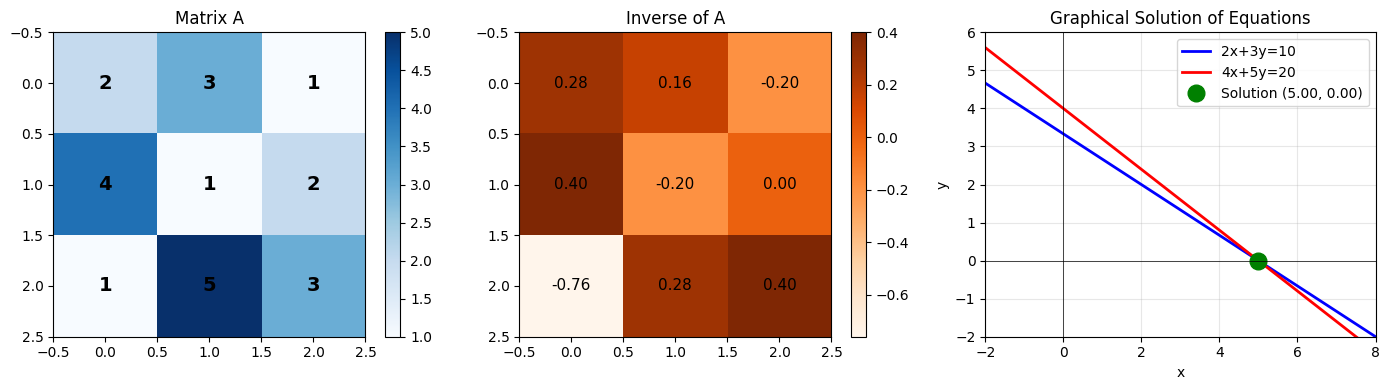

In [1]:
# ============================================
# PROJECT 5: Linear Algebra using NumPy
# SPPU Data Science Lab - PCC-255-CAI
# CO1: Implement Linear Algebra using Python
# ============================================

import numpy as np
import matplotlib.pyplot as plt

print("=" * 45)
print("   LINEAR ALGEBRA - NUMPY")
print("=" * 45)

# =====================
# PART A: 3x3 Matrix & Determinant
# =====================
A = np.array([[2, 3, 1],
              [4, 1, 2],
              [1, 5, 3]])

print("\n--- PART A: Matrix & Determinant ---")
print("Matrix A:")
print(A)

det = np.linalg.det(A)
print(f"\nDeterminant of A: {det:.4f}")

# =====================
# PART B: Inverse of Matrix
# =====================
print("\n--- PART B: Inverse of Matrix ---")
if abs(det) > 1e-10:
    A_inv = np.linalg.inv(A)
    print("Inverse of A:")
    print(np.round(A_inv, 4))

    # Verify: A * A_inv should = Identity matrix
    identity_check = np.round(A @ A_inv, 6)
    print("\nVerification (A × A_inv) = Identity:")
    print(identity_check)
else:
    print("Matrix is singular — inverse does not exist.")

# =====================
# PART C: Solve Linear Equations
# 2x + 3y = 10
# 4x + 5y = 20
# =====================
print("\n--- PART C: Solve Linear Equations ---")
print("Equations:")
print("  2x + 3y = 10")
print("  4x + 5y = 20")

coeff = np.array([[2, 3],
                  [4, 5]])
const = np.array([10, 20])

solution = np.linalg.solve(coeff, const)
print(f"\nSolution:")
print(f"  x = {solution[0]:.4f}")
print(f"  y = {solution[1]:.4f}")

# Verify
print("\nVerification:")
print(f"  2({solution[0]:.2f}) + 3({solution[1]:.2f}) = {2*solution[0]+3*solution[1]:.2f}  (expected 10)")
print(f"  4({solution[0]:.2f}) + 5({solution[1]:.2f}) = {4*solution[0]+5*solution[1]:.2f}  (expected 20)")

# =====================
# PART D: Eigenvalues & Eigenvectors
# =====================
print("\n--- PART D: Eigenvalues & Eigenvectors ---")
eigenvalues, eigenvectors = np.linalg.eig(A)
print("Eigenvalues:")
print(np.round(eigenvalues, 4))
print("\nEigenvectors:")
print(np.round(eigenvectors, 4))

# =====================
# PART E: Matrix Operations
# =====================
B = np.array([[1, 0, 2],
              [3, 1, 0],
              [0, 2, 1]])

print("\n--- PART E: Matrix Operations ---")
print("Matrix B:")
print(B)
print("\nA + B:")
print(A + B)
print("\nA × B (Matrix Multiplication):")
print(A @ B)
print("\nTranspose of A:")
print(A.T)

# =====================
# Visualization
# =====================
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Matrix A heatmap
im1 = axes[0].imshow(A, cmap='Blues', aspect='auto')
axes[0].set_title('Matrix A')
for i in range(3):
    for j in range(3):
        axes[0].text(j, i, str(A[i,j]), ha='center', va='center',
                     fontsize=14, fontweight='bold')
plt.colorbar(im1, ax=axes[0])

# Inverse heatmap
im2 = axes[1].imshow(A_inv, cmap='Oranges', aspect='auto')
axes[1].set_title('Inverse of A')
for i in range(3):
    for j in range(3):
        axes[1].text(j, i, f"{A_inv[i,j]:.2f}", ha='center', va='center', fontsize=11)
plt.colorbar(im2, ax=axes[1])

# Solution visualization
axes[2].set_xlim(-2, 8); axes[2].set_ylim(-2, 6)
x_vals = np.linspace(-2, 8, 300)
y1 = (10 - 2*x_vals) / 3
y2 = (20 - 4*x_vals) / 5
axes[2].plot(x_vals, y1, 'b-', linewidth=2, label='2x+3y=10')
axes[2].plot(x_vals, y2, 'r-', linewidth=2, label='4x+5y=20')
axes[2].plot(solution[0], solution[1], 'go', markersize=12, label=f'Solution ({solution[0]:.2f}, {solution[1]:.2f})')
axes[2].axhline(0, color='black', linewidth=0.5)
axes[2].axvline(0, color='black', linewidth=0.5)
axes[2].set_title('Graphical Solution of Equations')
axes[2].set_xlabel('x'); axes[2].set_ylabel('y')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('linear_algebra.png', dpi=100)
plt.show()